In [2]:
import pandas as pd

In [4]:
open_df = pd.read_csv("C:\\Users\\ekru\\Documents\\Cursor\\ganv2\\Project\\Dataset Creation\\ODKG_triplets.csv")
sider_df = pd.read_csv("C:\\Users\\ekru\\Documents\\Cursor\\ganv2\\Project\\Dataset Creation\\SIDER_triplets.csv")

combined_df = pd.concat([open_df, sider_df], ignore_index=True)
combined_df = combined_df.sample(frac=1, random_state=42).reset_index(drop=True)
print(combined_df)


                                                  Head        Relation  \
0                               Fluocinolone acetonide  INTERACTS_WITH   
1                                           Tazarotene  INTERACTS_WITH   
2                                            Guanoclor  INTERACTS_WITH   
3                          Dexamethasone isonicotinate  INTERACTS_WITH   
4                                         Sparfloxacin  INTERACTS_WITH   
...                                                ...             ...   
467009  1-(2-Phenylethyl)-4-phenyl-4-acetoxypiperidine  INTERACTS_WITH   
467010                                      Thiopental  INTERACTS_WITH   
467011                                       Zanamivir  INTERACTS_WITH   
467012                                     Catumaxomab  INTERACTS_WITH   
467013                                        Talopram  INTERACTS_WITH   

                                     Tail  
0                                Abetimus  
1                      

In [5]:
combined_df.to_csv("Final_Graph.csv", index=False)


In [3]:
df = pd.read_csv("C:\\Users\\ekru\\Documents\\Cursor\\ganv2\\Project\\Dataset Creation\\Final_Graph.csv")
relations = ["INTERACTS_WITH", "TREATED_BY", "HAS_PRICE", "AVAILABLE_AT", "MANUFACTURED_BY", "IN_PRODUCT","HAS_SIDE_EFFECT"]

random_samples_list = []


for relation in relations:
    filtered_df = df[df['Relation'] == relation]
    
    if not filtered_df.empty:
        random_sample = filtered_df.sample(n=1)
        random_samples_list.append(random_sample)

random_samples_df = pd.concat(random_samples_list)
random_samples_df.reset_index(drop=True, inplace=True)

print(random_samples_df[['Head', 'Relation', 'Tail']])

                      Head         Relation                    Tail
0        Magnesium acetate   INTERACTS_WITH       Magnesium sulfate
1    AIDS dementia complex       TREATED_BY               Maraviroc
2                   Geodon        HAS_PRICE                 11.8048
3                   107.61     AVAILABLE_AT            Target (CVS)
4                   Ranexa  MANUFACTURED_BY  Gilead Palo Alto, Inc.
5  Verticillium albo-atrum       IN_PRODUCT            Verticillium
6               Octreotide  HAS_SIDE_EFFECT        Mouth ulceration


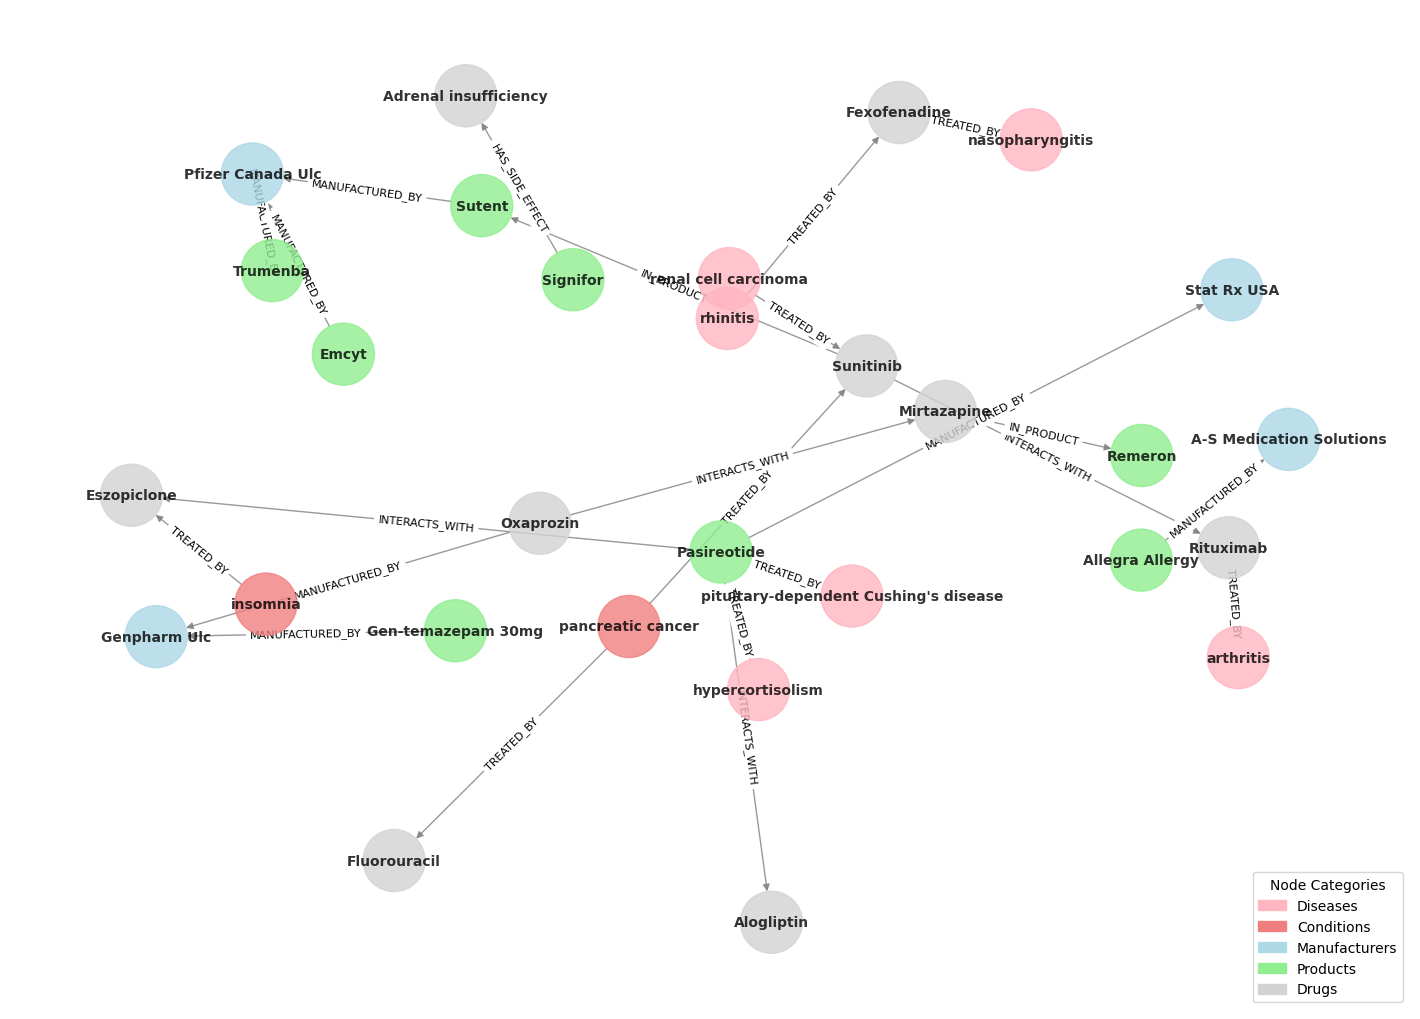

In [17]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from io import StringIO

# Load CSV Data
csv_data = """Head,Relation,Tail
Sunitinib,INTERACTS_WITH,Rituximab
pancreatic cancer,TREATED_BY,Sunitinib
renal cell carcinoma,TREATED_BY,Sunitinib
Sunitinib,IN_PRODUCT,Sutent
Sutent,MANUFACTURED_BY,Pfizer Canada Ulc
arthritis,TREATED_BY,Rituximab
pancreatic cancer,TREATED_BY,Fluorouracil
Trumenba,MANUFACTURED_BY,Pfizer Canada Ulc
Emcyt,MANUFACTURED_BY,Pfizer Canada Ulc
hypercortisolism,TREATED_BY,Pasireotide
pituitary-dependent Cushing's disease,TREATED_BY,Pasireotide
Pasireotide,INTERACTS_WITH,Eszopiclone
Pasireotide,INTERACTS_WITH,Alogliptin
Signifor,HAS_SIDE_EFFECT,Adrenal insufficiency
Pasireotide,MANUFACTURED_BY,Stat Rx USA
insomnia,TREATED_BY,Eszopiclone
Gen-temazepam 30mg,MANUFACTURED_BY,Genpharm Ulc
Oxaprozin,MANUFACTURED_BY,Genpharm Ulc
Oxaprozin,INTERACTS_WITH,Mirtazapine
Mirtazapine,IN_PRODUCT,Remeron
Allegra Allergy,MANUFACTURED_BY,A-S Medication Solutions
nasopharyngitis,TREATED_BY,Fexofenadine
rhinitis,TREATED_BY,Fexofenadine
"""

# Convert CSV to DataFrame
df = pd.read_csv(StringIO(csv_data))

# Create Knowledge Graph
G = nx.DiGraph()

# Add nodes and edges
for _, row in df.iterrows():
    G.add_node(row["Head"], label=row["Head"])
    G.add_node(row["Tail"], label=row["Tail"])
    G.add_edge(row["Head"], row["Tail"], relation=row["Relation"])

# Define node colors based on type
node_colors = []
color_map = {}

# List of disease-related keywords
disease_keywords = ["disease", "syndrome", "itis", "hyper", "cortisolism", "nasopharyngitis", "rhinitis","carcinoma"]

for node in G.nodes():
    node_lower = node.lower()
    
    if any(keyword in node_lower for keyword in disease_keywords):
        node_colors.append("lightpink")  # Diseases in Pink
        color_map[node] = "lightpink"
    elif any(condition in node_lower for condition in ["cancer", "arthritis", "insomnia"]):
        node_colors.append("lightcoral")  # Conditions in Red
        color_map[node] = "lightcoral"
    elif any(company in node for company in ["Inc", "Solutions", "Ulc","Rx"]):
        node_colors.append("lightblue")  # Manufacturers in Blue
        color_map[node] = "lightblue"
    elif any(product in node for product in ["mg", "Sutent", "Signifor","Remeron","Trumenba","Emcyt","Pasireotide","Allegra Allergy"]):
        node_colors.append("lightgreen")  # Products in Green
        color_map[node] = "lightgreen"
    else:
        node_colors.append("lightgray")  # Default for Drugs
        color_map[node] = "lightgray"

# Draw the graph
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, seed=42, k=0.5)

nx.draw(G, pos, with_labels=True, node_color=node_colors, edge_color="gray",
        node_size=2000, font_size=10, font_weight="bold", alpha=0.8, edge_cmap=plt.cm.Blues)

# Add edge labels
edge_labels = {(u, v): d['relation'] for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8, font_color="black")

# Update Legend
legend_patches = [
    mpatches.Patch(color="lightpink", label="Diseases"),
    mpatches.Patch(color="lightcoral", label="Conditions"),
    mpatches.Patch(color="lightblue", label="Manufacturers"),
    mpatches.Patch(color="lightgreen", label="Products"),
    mpatches.Patch(color="lightgray", label="Drugs")
]

plt.legend(handles=legend_patches, loc="lower right", fontsize=10, title="Node Categories")
plt.show()
